# 🧠 Salud Mental en Adolescentes y Uso de Redes Sociales
## Clasificación Supervisada: Bajo / Medio / Alto
**Universidad Galileo — Manejo de Datos para la IA**

## 1. Instalación e Importación de Librerías

In [1]:
# Instalar kaggle si no está disponible
!pip install kaggle --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Librerías cargadas correctamente')

/Users/kevs/Documents/DEV_PROJECTS/6. GALILEO/manejo-datos-ia/proyect-manejo-datos-galileo/venv/bin/pip: line 2: /Users/kevs/Documents/DEV_PROJECTS/6. GALILEO/manejo-datos-ia/proyect-manejo-datos.galileo/venv/bin/python3: No such file or directory
/Users/kevs/Documents/DEV_PROJECTS/6. GALILEO/manejo-datos-ia/proyect-manejo-datos-galileo/venv/bin/pip: line 2: exec: /Users/kevs/Documents/DEV_PROJECTS/6. GALILEO/manejo-datos-ia/proyect-manejo-datos.galileo/venv/bin/python3: cannot execute: No such file or directory
✅ Librerías cargadas correctamente


## 2. Descarga del Dataset desde Kaggle

Las credenciales se cargan automáticamente desde el archivo `.env` del proyecto.

In [3]:
import os
import json
from dotenv import load_dotenv

# Cargar credenciales desde .env
load_dotenv()

kaggle_username = os.getenv('KAGGLE_USERNAME')
kaggle_key = os.getenv('KAGGLE_KEY')

if not kaggle_username or not kaggle_key:
    raise ValueError('❌ Falta KAGGLE_USERNAME o KAGGLE_KEY en el archivo .env')

# Crear el archivo kaggle.json que necesita la librería
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')
with open(kaggle_json_path, 'w') as f:
    json.dump({'username': kaggle_username, 'key': kaggle_key}, f)

os.chmod(kaggle_json_path, 0o600)

print(f'✅ Credenciales configuradas para: {kaggle_username}')

✅ Credenciales configuradas para: kevinarguetagalileo


In [4]:
# Descargar el dataset
!kaggle datasets download -d algozee/teenager-menthal-healy --unzip

# Ver qué archivos se descargaron
!ls -lh

/Users/kevs/Documents/DEV_PROJECTS/6. GALILEO/manejo-datos-ia/proyect-manejo-datos-galileo/venv/bin/kaggle: line 2: /Users/kevs/Documents/DEV_PROJECTS/6. GALILEO/manejo-datos-ia/proyect-manejo-datos.galileo/venv/bin/python3: No such file or directory
/Users/kevs/Documents/DEV_PROJECTS/6. GALILEO/manejo-datos-ia/proyect-manejo-datos-galileo/venv/bin/kaggle: line 2: exec: /Users/kevs/Documents/DEV_PROJECTS/6. GALILEO/manejo-datos-ia/proyect-manejo-datos.galileo/venv/bin/python3: cannot execute: No such file or directory
total 2352
-r--------@ 1 kevs  staff   116K May 26 21:41 Proyecto_instrucciones.pdf
-rw-r--r--@ 1 kevs  staff    61K May 26 22:07 Teen_Mental_Health_Dataset.csv
-rw-r--r--@ 1 kevs  staff    35K May 26 23:11 grafica_categorica_target.png
-rw-r--r--@ 1 kevs  staff    27K May 26 23:11 grafica_confusion.png
-rw-r--r--@ 1 kevs  staff   164K May 26 23:11 grafica_correlacion.png
-rw-r--r--@ 1 kevs  staff    66K May 26 23:11 grafica_distribucion_target.png
-rw-r--r--@ 1 kevs  sta

## 3. Carga del Dataset

In [5]:
import glob

# Encontrar el archivo CSV automáticamente
csv_files = glob.glob('*.csv')
print('Archivos CSV encontrados:', csv_files)

# Cargar el primero que encuentre
df = pd.read_csv(csv_files[0])

print(f'\n✅ Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Archivos CSV encontrados: ['Teen_Mental_Health_Dataset.csv']

✅ Dataset cargado: 1200 filas x 13 columnas


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## 4. Exploración Básica del Dataset (EDA)

In [7]:
print('=== INFORMACIÓN GENERAL ===')
df.info()

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)


In [8]:
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe(include='all')

=== ESTADÍSTICAS DESCRIPTIVAS ===


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN
freq,NaN,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN
mean,15.928333,NaN,4.536667,NaN,6.449417,1.740333,2.990383,1.014500,NaN,5.445833,5.636667,5.565000,0.025833
std,2.021947,NaN,2.029599,NaN,1.442677,0.716660,0.576758,0.582185,NaN,2.903290,2.859453,2.830627,0.158704
min,13.000000,NaN,1.000000,NaN,4.000000,0.500000,2.000000,0.000000,NaN,1.000000,1.000000,1.000000,0.000000
25%,14.000000,NaN,2.800000,NaN,5.200000,1.100000,2.500000,0.500000,NaN,3.000000,3.000000,3.000000,0.000000
50%,16.000000,NaN,4.500000,NaN,6.500000,1.800000,2.990000,1.000000,NaN,5.000000,6.000000,6.000000,0.000000
75%,18.000000,NaN,6.300000,NaN,7.600000,2.400000,3.480000,1.500000,NaN,8.000000,8.000000,8.000000,0.000000


In [9]:
print('=== COLUMNAS DEL DATASET ===')
for i, col in enumerate(df.columns):
    print(f'{i+1}. {col} — tipo: {df[col].dtype}')

=== COLUMNAS DEL DATASET ===
1. age — tipo: int64
2. gender — tipo: object
3. daily_social_media_hours — tipo: float64
4. platform_usage — tipo: object
5. sleep_hours — tipo: float64
6. screen_time_before_sleep — tipo: float64
7. academic_performance — tipo: float64
8. physical_activity — tipo: float64
9. social_interaction_level — tipo: object
10. stress_level — tipo: int64
11. anxiety_level — tipo: int64
12. addiction_level — tipo: int64
13. depression_label — tipo: int64


## 5. Limpieza de Datos

In [10]:
print('=== VALORES NULOS POR COLUMNA ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ No hay valores nulos')

print(f'\n=== FILAS DUPLICADAS: {df.duplicated().sum()} ===')

=== VALORES NULOS POR COLUMNA ===
✅ No hay valores nulos

=== FILAS DUPLICADAS: 0 ===


In [11]:
# Eliminar duplicados si los hay
df = df.drop_duplicates()

# Llenar nulos numéricos con la mediana
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Llenar nulos categóricos con la moda
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f'✅ Dataset limpio: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Dataset limpio: 1200 filas x 13 columnas


## 6. Visualizaciones (EDA Gráfico)

> **IMPORTANTE:** Antes de correr esta sección, identifica cuál es tu variable objetivo.
> Es la columna que indica el nivel de afectación (Bajo/Medio/Alto).
> Cámbiala en la celda siguiente.

In [13]:
# Mostrar todas las columnas disponibles
print('=== COLUMNAS DEL DATASET ===')
for i, col in enumerate(df.columns):
    print(f'{i+1}. {col}')

# Intentar detectar la columna objetivo automáticamente
keywords = ['mental', 'health', 'level', 'impact', 'affect', 'score', 'label', 'class', 'target']
candidatas = [col for col in df.columns if any(k in col.lower() for k in keywords)]

if candidatas:
    TARGET_COLUMN = candidatas[0]
    print(f'\n✅ Columna objetivo detectada: "{TARGET_COLUMN}"')
else:
    # Si no se detecta automáticamente, cambiar manualmente aquí
    TARGET_COLUMN = df.columns[-1]  # toma la última columna como fallback
    print(f'\n⚠️  No se detectó automáticamente. Usando última columna: "{TARGET_COLUMN}"')
    print('Si no es correcta, cámbiala manualmente en TARGET_COLUMN')

print(f'\nValores únicos: {df[TARGET_COLUMN].unique()}')
print(df[TARGET_COLUMN].value_counts())

=== COLUMNAS DEL DATASET ===
1. age
2. gender
3. daily_social_media_hours
4. platform_usage
5. sleep_hours
6. screen_time_before_sleep
7. academic_performance
8. physical_activity
9. social_interaction_level
10. stress_level
11. anxiety_level
12. addiction_level
13. depression_label

✅ Columna objetivo detectada: "social_interaction_level"

Valores únicos: ['low' 'high' 'medium']
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


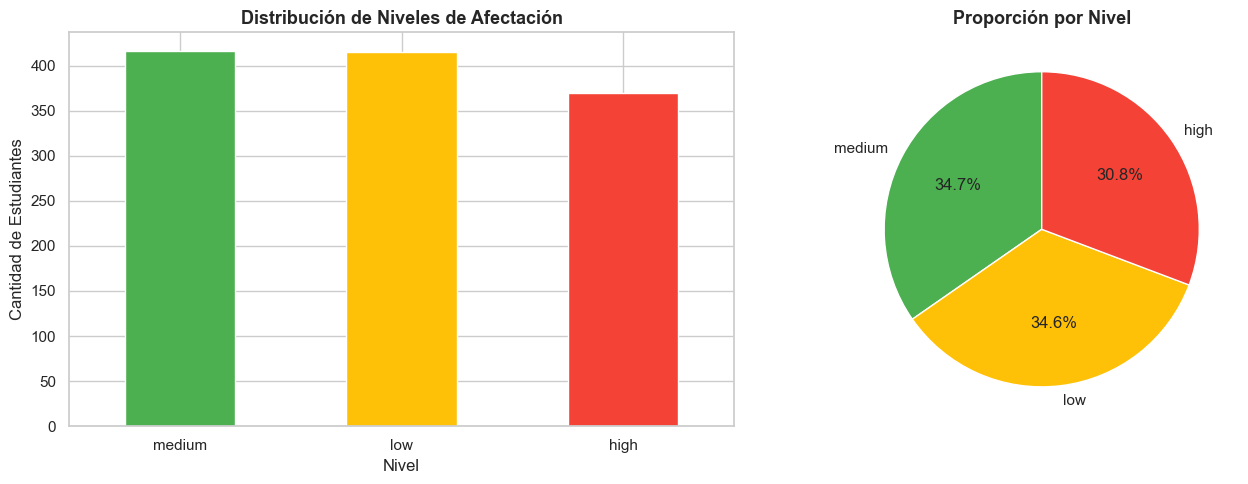

✅ Gráfica guardada


In [14]:
# Gráfica 1: Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conteo = df[TARGET_COLUMN].value_counts()
conteo.plot(kind='bar', ax=axes[0], color=['#4CAF50','#FFC107','#F44336'], edgecolor='white')
axes[0].set_title('Distribución de Niveles de Afectación', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nivel')
axes[0].set_ylabel('Cantidad de Estudiantes')
axes[0].tick_params(axis='x', rotation=0)

conteo.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
            colors=['#4CAF50','#FFC107','#F44336'], startangle=90)
axes[1].set_title('Proporción por Nivel', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('grafica_distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada')

Variables numéricas encontradas: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


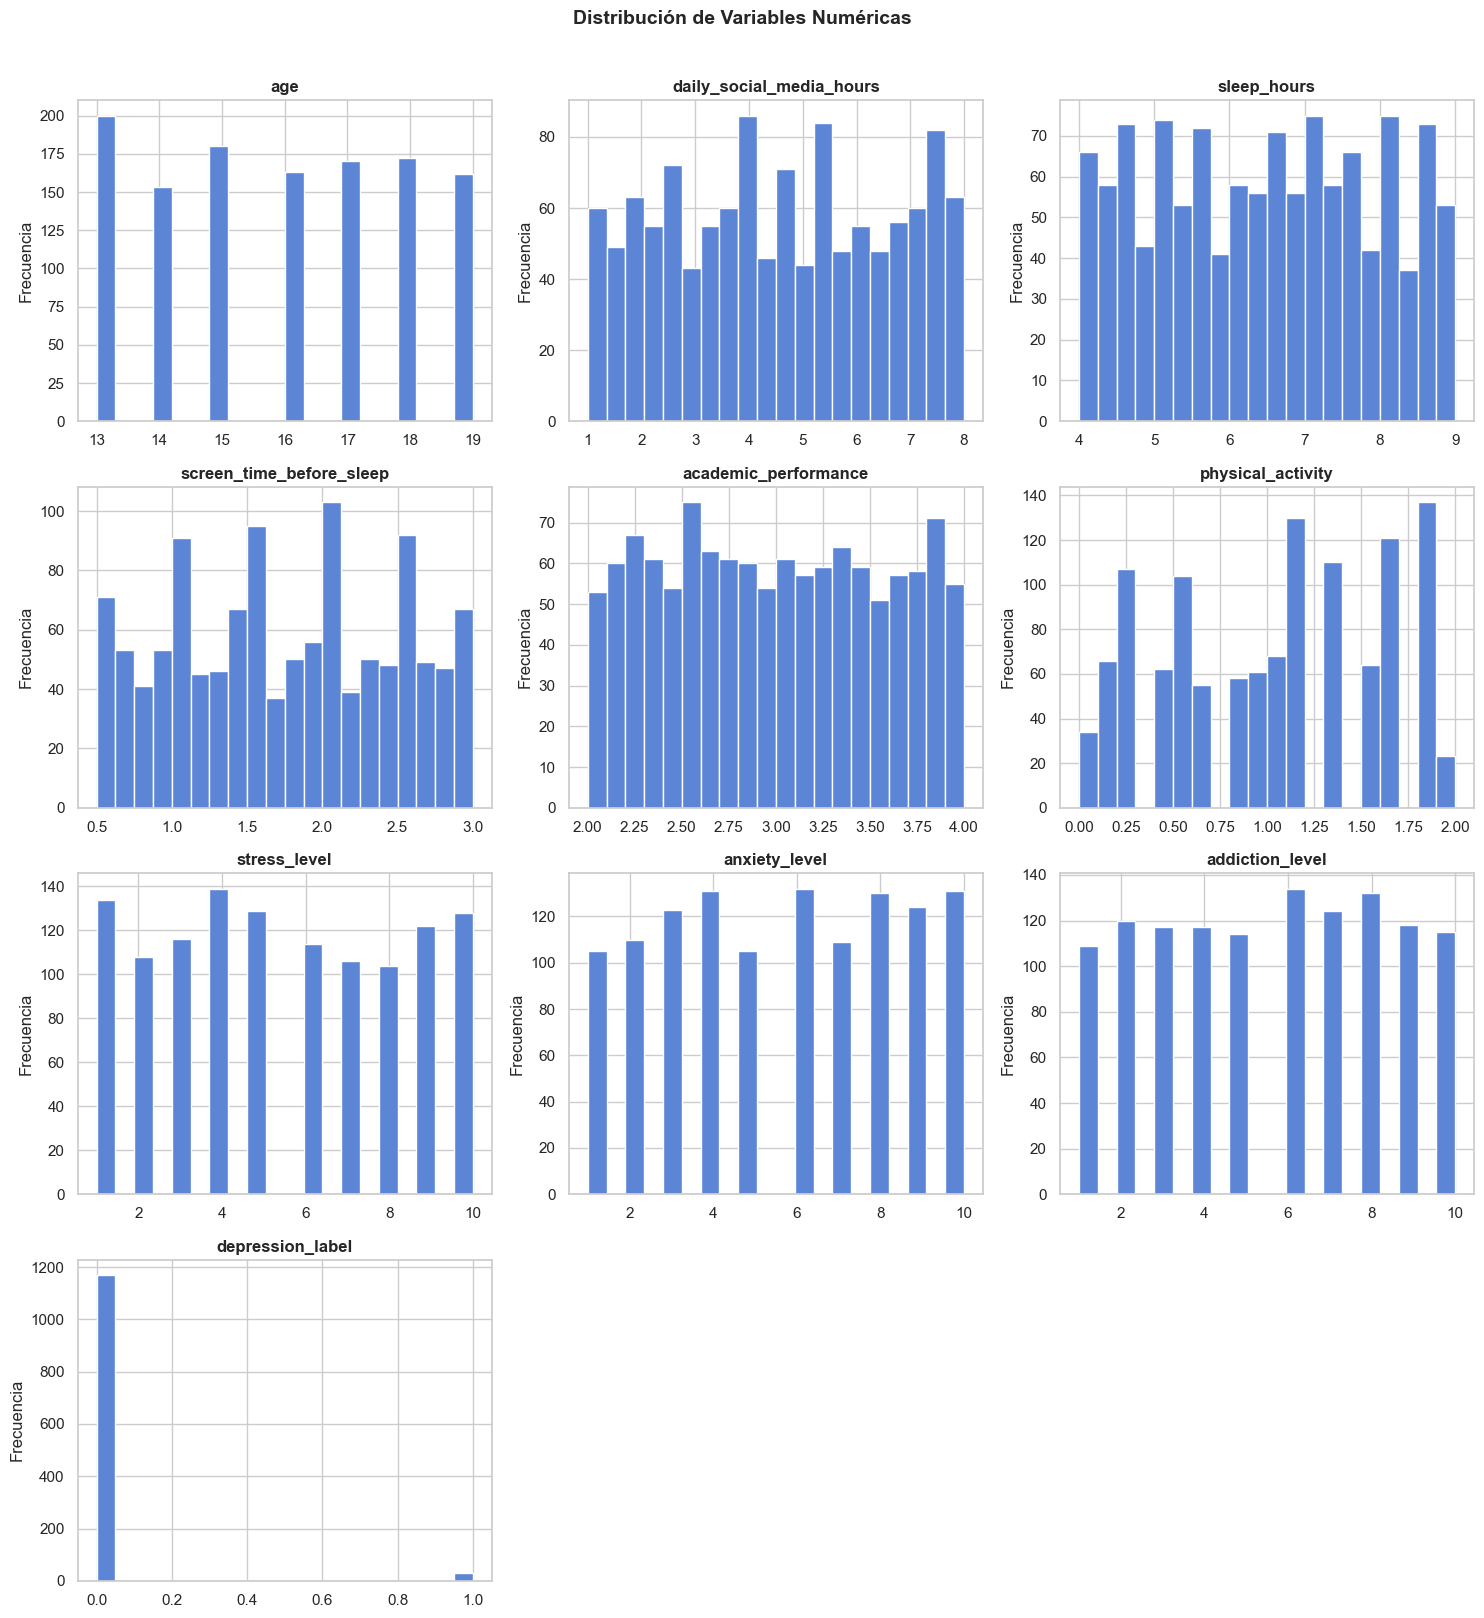

✅ Gráfica guardada


In [15]:
# Gráfica 2: Distribución de variables numéricas
numericas = df.select_dtypes(include='number').columns.tolist()
print(f'Variables numéricas encontradas: {numericas}')

if len(numericas) > 0:
    n = len(numericas)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(numericas):
        df[col].hist(ax=axes[i], bins=20, color='#5C85D6', edgecolor='white')
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_ylabel('Frecuencia')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('grafica_numericas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Gráfica guardada')

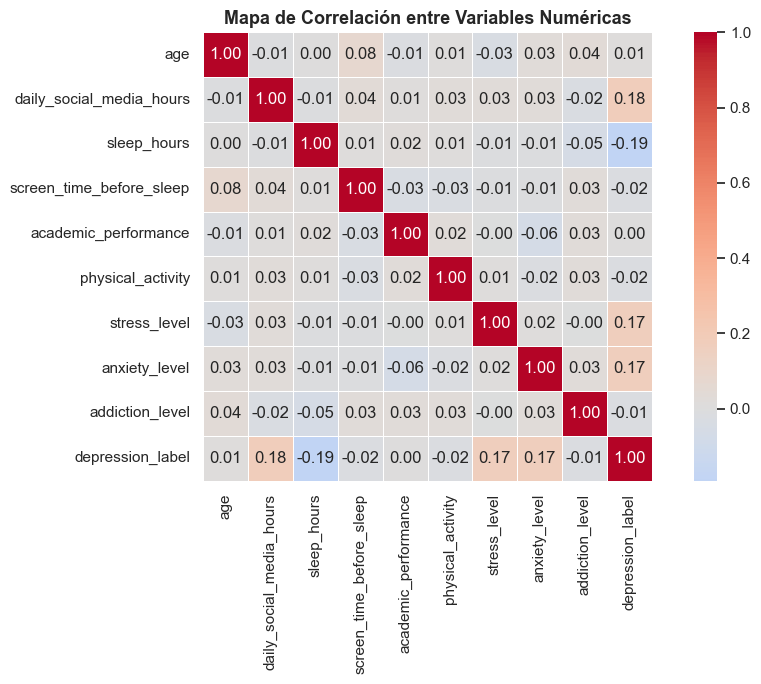

✅ Gráfica guardada


In [16]:
# Gráfica 3: Correlación entre variables numéricas
if len(numericas) > 1:
    plt.figure(figsize=(10, 7))
    corr_matrix = df[numericas].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5)
    plt.title('Mapa de Correlación entre Variables Numéricas', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafica_correlacion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Gráfica guardada')

Variables categóricas: ['gender', 'platform_usage']


<Figure size 1000x500 with 0 Axes>

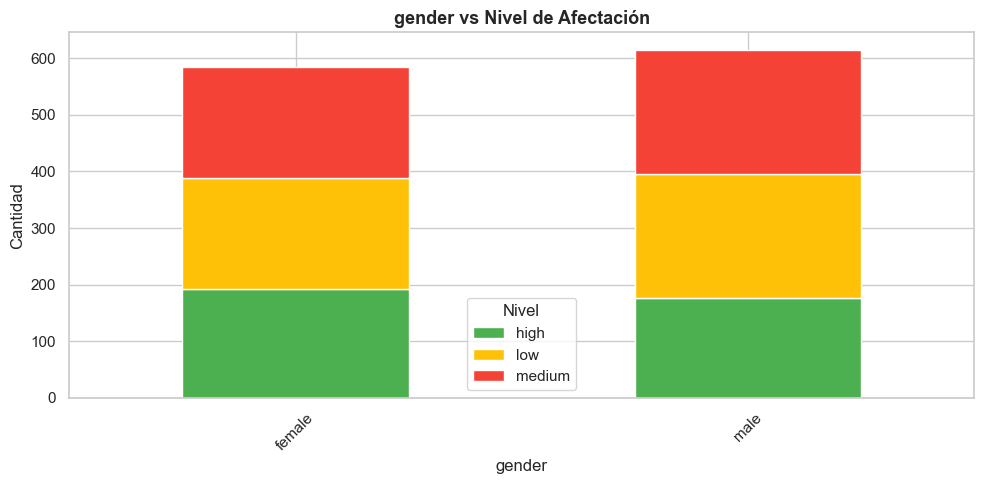

✅ Gráfica guardada


In [17]:
# Gráfica 4: Variables categóricas vs Target
categoricas = df.select_dtypes(include='object').columns.tolist()
if TARGET_COLUMN in categoricas:
    categoricas.remove(TARGET_COLUMN)

print(f'Variables categóricas: {categoricas}')

if len(categoricas) > 0:
    col_cat = categoricas[0]  # Toma la primera categórica
    plt.figure(figsize=(10, 5))
    ct = pd.crosstab(df[col_cat], df[TARGET_COLUMN])
    ct.plot(kind='bar', stacked=True, color=['#4CAF50','#FFC107','#F44336'], edgecolor='white')
    plt.title(f'{col_cat} vs Nivel de Afectación', fontsize=13, fontweight='bold')
    plt.xlabel(col_cat)
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45)
    plt.legend(title='Nivel')
    plt.tight_layout()
    plt.savefig('grafica_categorica_target.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Gráfica guardada')

## 7. Preparación de Datos para el Modelo

In [19]:
df_modelo = df.copy()

# Codificar variables categóricas a números
le = LabelEncoder()
for col in df_modelo.select_dtypes(include='object').columns:
    df_modelo[col] = le.fit_transform(df_modelo[col].astype(str))
    print(f'✅ Codificada: {col}')

print(f'\n📊 Dataset listo para el modelo: {df_modelo.shape}')
df_modelo.head()

✅ Codificada: gender
✅ Codificada: platform_usage
✅ Codificada: social_interaction_level

📊 Dataset listo para el modelo: (1200, 13)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0


In [20]:
# Separar features (X) y variable objetivo (y)
TARGET_COL_NUM = TARGET_COLUMN  # misma columna, ya codificada

X = df_modelo.drop(columns=[TARGET_COL_NUM])
y = df_modelo[TARGET_COL_NUM]

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train: {X_train.shape[0]} muestras')
print(f'✅ Test:  {X_test.shape[0]} muestras')
print(f'✅ Features: {X_train.shape[1]} variables')

✅ Train: 960 muestras
✅ Test:  240 muestras
✅ Features: 12 variables


## 8. Entrenamiento del Modelo — Random Forest

In [21]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

print('✅ Modelo entrenado')

✅ Modelo entrenado


## 9. Evaluación del Modelo

In [22]:
y_pred = modelo.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'🎯 Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print('\n=== Reporte de Clasificación ===')
print(classification_report(y_test, y_pred))

🎯 Accuracy: 0.3417 (34.17%)

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.32      0.19      0.24        74
           1       0.33      0.33      0.33        83
           2       0.36      0.49      0.42        83

    accuracy                           0.34       240
   macro avg       0.34      0.34      0.33       240
weighted avg       0.34      0.34      0.33       240



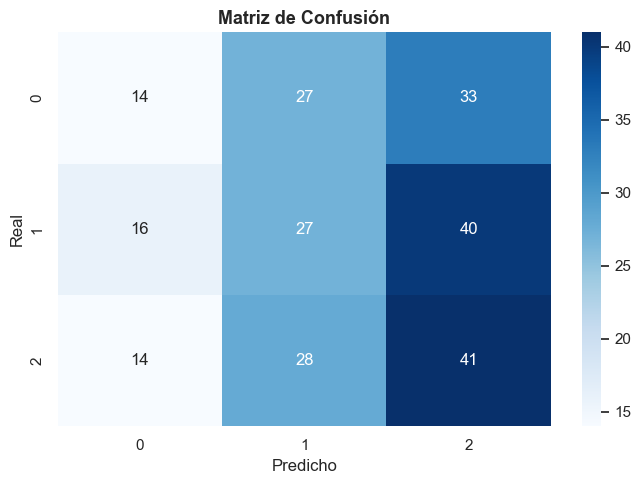

In [23]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.title('Matriz de Confusión', fontsize=13, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('grafica_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

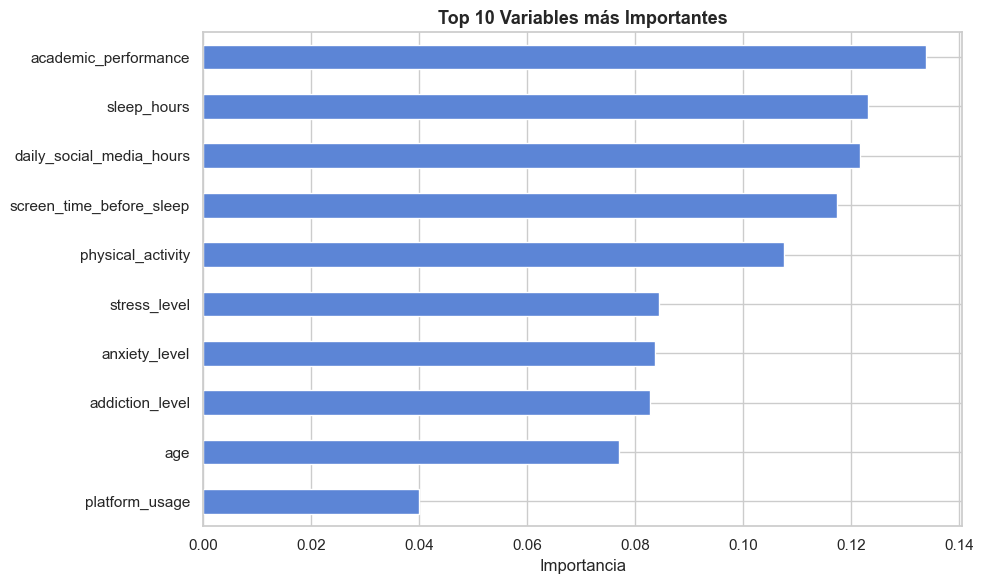

In [24]:
# Variables más importantes para la predicción
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.tail(10).plot(kind='barh', color='#5C85D6', edgecolor='white')
plt.title('Top 10 Variables más Importantes', fontsize=13, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('grafica_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Resumen Final

In [25]:
print('=' * 50)
print('     RESUMEN DEL PROYECTO')
print('=' * 50)
print(f'Dataset: {df.shape[0]} registros, {df.shape[1]} columnas')
print(f'Variable objetivo: {TARGET_COLUMN}')
print(f'Clases: {df[TARGET_COLUMN].unique()}')
print(f'Modelo: Random Forest (100 árboles)')
print(f'Accuracy: {acc*100:.2f}%')
print(f'Variable más importante: {importancias.idxmax()}')
print('=' * 50)

     RESUMEN DEL PROYECTO
Dataset: 1200 registros, 13 columnas
Variable objetivo: social_interaction_level
Clases: ['low' 'high' 'medium']
Modelo: Random Forest (100 árboles)
Accuracy: 34.17%
Variable más importante: academic_performance
